# What is about ?

Get info on the genes used in MOA kaggle competition by MYGENE Python package.
See https://www.kaggle.com/alexandervc/genes-info-with-mygene-python-package
for info on that package.



In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/genes-information/Tirosh_genes_info_cell_97_main_cycle_regulators.csv
/kaggle/input/genes-information/genes_human_ALS_disease_related_from_alsod_ac_uk.csv
/kaggle/input/lish-moa/train_targets_scored.csv
/kaggle/input/lish-moa/sample_submission.csv
/kaggle/input/lish-moa/train_drug.csv
/kaggle/input/lish-moa/train_targets_nonscored.csv
/kaggle/input/lish-moa/train_features.csv
/kaggle/input/lish-moa/test_features.csv


# Load data with Entrez id provided by competition organizers after the end of the competition

In [2]:
url = 'https://github.com/LISHarvard/moa_challenge/blob/master/gene_mapping.csv'
url = 'https://raw.githubusercontent.com/LISHarvard/moa_challenge/master/gene_mapping.csv'
# Official link taken from: https://www.kaggle.com/c/lish-moa/discussion/207259

# Old - Entrez ID, New - used in competition

df = pd.read_csv(url, sep = ',')
df

,old,new
0,16,g-0
1,23,g-1
2,25,g-2
3,30,g-3
4,47,g-4
...,...,...
767,116832,g-767
768,148022,g-768
769,200734,g-769
770,256364,g-770


# MYGENE package install and simple use example

In [3]:
pip install mygene


Note: you may need to restart the kernel to use updated packages.


In [4]:
import mygene

In [5]:
mg = mygene.MyGeneInfo()


In [6]:
i = 0
g = df.iloc[i,0]

g = mg.getgene(g)#
g.keys()

dict_keys(['HGNC', 'MIM', '_id', '_version', 'accession', 'alias', 'clingen', 'ec', 'ensembl', 'entrezgene', 'exac', 'exons', 'exons_hg19', 'generif', 'genomic_pos', 'genomic_pos_hg19', 'go', 'homologene', 'interpro', 'ipi', 'map_location', 'name', 'other_names', 'pantherdb', 'pathway', 'pdb', 'pfam', 'pharmgkb', 'pharos', 'pir', 'prosite', 'reagent', 'refseq', 'reporter', 'summary', 'symbol', 'taxid', 'type_of_gene', 'umls', 'unigene', 'uniprot'])

In [7]:
g[ 'symbol']

'AARS1'

In [8]:
g['type_of_gene']

'protein-coding'

In [9]:
g['alias']

['AARS', 'CMT2N', 'DEE29', 'EIEE29']

# Get names of all genes

In [10]:
import time
list_genes_symbols  = []#  df.copy()
t0 = time.time()
for i in range(len(df)):
    entrez_gene_ID = df['old'].iat[i]
    kaggle_id = df['new'].iat[i]
    try:
        g_inf = mg.getgene(entrez_gene_ID)
        list_genes_symbols.append(g_inf['symbol'])
    except:
        print('Exception', kaggle_id,entrez_gene_ID )
        
print( 'Finished. Seconds passed: ',  np.round(time.time() - t0 ,1))
print( list_genes_symbols )        

Finished. Seconds passed:  99.3
['AARS1', 'ABCF1', 'ABL1', 'ACAA1', 'ACLY', 'ADAM10', 'ADH5', 'PARP1', 'ADRB2', 'AGL', 'AKT1', 'ALAS1', 'ALDOA', 'ALDOC', 'SLC25A4', 'ANXA7', 'APBB2', 'BIRC2', 'APOE', 'APP', 'FAS', 'RHOA', 'ASAH1', 'ATP1B1', 'ALDH7A1', 'ATP6V0B', 'BAD', 'BAX', 'CCND1', 'BCL2', 'BDH1', 'BID', 'BLMH', 'BMP4', 'BNIP3', 'BPHL', 'BRCA1', 'BUB1B', 'C5', 'DDR1', 'CALU', 'CAPN1', 'CAST', 'CASP2', 'CASP3', 'CASP7', 'CASP10', 'CAT', 'CBLB', 'CBR1', 'CCNA2', 'CCND3', 'CCNF', 'SCARB1', 'CD40', 'CD44', 'CD58', 'ADGRE5', 'CDC20', 'CDC25A', 'CDC25B', 'CDC42', 'CDH3', 'CDK2', 'CDK6', 'CDKN1A', 'CDKN1B', 'CDKN2A', 'CEBPA', 'CEBPD', 'CENPE', 'CETN3', 'CHEK1', 'CIRBP', 'CLTB', 'COL1A1', 'CREB1', 'CRK', 'CRYZ', 'CSK', 'CSNK1A1', 'CSNK1E', 'CSRP1', 'CTNND1', 'CTSD', 'CTSL', 'CYB561', 'DAG1', 'DAXX', 'DCTD', 'DDB2', 'GADD45A', 'DDX10', 'DECR1', 'DFFB', 'DNM1', 'DNMT1', 'DNMT3A', 'DPH2', 'DSG2', 'TSC22D3', 'DUSP3', 'DUSP4', 'TOR1A', 'E2F2', 'ECH1', 'EDN1', 'EGFR', 'EIF4EBP1', 'EIF4G1', 'EIF5'

# Get info on all genes from the list and save to  csv file

In [11]:
import time
genes = df.copy()
t0 = time.time()
for i in range(len(df)):
    entrez_gene_ID = df['old'].iat[i]
    kaggle_id = df['new'].iat[i]
    
    try:
        g = mg.getgene(entrez_gene_ID)
        #print(i,ens_id)
        #print(g.keys())

        IX = genes.index[i]
        list1 = ['symbol',   'type_of_gene', 'map_location' ,   'name', 'entrezgene', 'alias', 'other_names'  ] 
        for k in list1:
            if k in g.keys():
                genes.loc[IX,k] = str(g[k])
        if  ('genomic_pos_hg19' in g.keys()) and ( isinstance(g['genomic_pos_hg19'], dict) ):
            for k in ['chr','start','end', 'strand' ]:
                if k in g['genomic_pos_hg19'].keys():
                    genes.loc[IX,k] = (g['genomic_pos_hg19'][k])
        if 'generif' in g.keys():
            genes.loc[IX,'count pubmed'] = len(g['generif'])
        if 'summary' in g.keys():
            genes.loc[IX,'summary'] = g['summary']
    except:
        print()
        print('Exception')
        print('i', i , 'entrez_gene_ID' , entrez_gene_ID, 'kaggle_id', kaggle_id )
        pass
    
    if i%500 == 0:
        print(i, np.round(time.time() - t0 ,1))
    if i >= 10e10:
        break

print(i, 'Finished. Seconds passed: ',  np.round(time.time() - t0 ,1))
        
genes['len'] = genes['end'] - genes['start']
genes

0 0.1
500 67.3
771 Finished. Seconds passed:  100.7


,old,new,symbol,type_of_gene,map_location,name,entrezgene,alias,other_names,chr,start,end,strand,count pubmed,summary,len
0,16,g-0,AARS1,protein-coding,16q22.1,alanyl-tRNA synthetase 1,16,"['AARS', 'CMT2N', 'DEE29', 'EIEE29']","['alaRS', 'alanine tRNA ligase 1, cytoplasmic'...",16,70286198.0,70323446.0,-1.0,12.0,The human alanyl-tRNA synthetase (AARS) belong...,37248.0
1,23,g-1,ABCF1,protein-coding,6p21.33,ATP binding cassette subfamily F member 1,23,"['ABC27', 'ABC50']",['ATP-binding cassette 50 (TNF-alpha stimulate...,NaN,NaN,NaN,NaN,19.0,The protein encoded by this gene is a member o...,NaN
2,25,g-2,ABL1,protein-coding,9q34.12,"ABL proto-oncogene 1, non-receptor tyrosine ki...",25,"['ABL', 'BCR-ABL', 'CHDSKM', 'JTK7', 'bcr/abl'...",['ABL protooncogene 1 nonreceptor tyrosine kin...,9,133589333.0,133763062.0,1.0,521.0,This gene is a protooncogene that encodes a pr...,173729.0
3,30,g-3,ACAA1,protein-coding,3p22.2,acetyl-CoA acyltransferase 1,30,"['ACAA', 'PTHIO', 'THIO']","['3-ketoacyl-CoA thiolase, peroxisomal', 'acet...",3,38144620.0,38178733.0,-1.0,10.0,This gene encodes an enzyme operative in the b...,34113.0
4,47,g-4,ACLY,protein-coding,17q21.2,ATP citrate lyase,47,"['ACL', 'ATPCL', 'CLATP']","['ATP-citrate (pro-S-)-lyase', 'ATP-citrate sy...",NaN,NaN,NaN,NaN,52.0,ATP citrate lyase is the primary enzyme respon...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,116832,g-767,RPL39L,protein-coding,3q27.3,ribosomal protein L39 like,116832,"['L39-2', 'RPL39L1']","['60S ribosomal protein L39-2', '60S ribosomal...",3,186838736.0,186898696.0,-1.0,4.0,This gene encodes a protein sharing high seque...,59960.0
768,148022,g-768,TICAM1,protein-coding,19p13.3,toll like receptor adaptor molecule 1,148022,"['IIAE6', 'MyD88-3', 'PRVTIRB', 'TICAM-1', 'TR...",['TIR domain containing adaptor inducing inter...,19,4815944.0,4831716.0,-1.0,92.0,This gene encodes an adaptor protein containin...,15772.0
769,200734,g-769,SPRED2,protein-coding,2p14,sprouty related EVH1 domain containing 2,200734,Spred-2,"['sprouty protein with EVH-1 domain 2, related...",2,65537985.0,65659771.0,-1.0,24.0,SPRED2 is a member of the Sprouty (see SPRY1; ...,121786.0
770,256364,g-770,EML3,protein-coding,11q12.3,EMAP like 3,256364,"['ELP95', 'EMAP3', 'EMAP95']","['EMAP-3', 'echinoderm microtubule associated ...",11,62369690.0,62380237.0,-1.0,2.0,NaN,10547.0


In [12]:
genes.to_csv('genes_info_MOA_kaggle.csv')


In [13]:
genes.head(10)


,old,new,symbol,type_of_gene,map_location,name,entrezgene,alias,other_names,chr,start,end,strand,count pubmed,summary,len
0,16,g-0,AARS1,protein-coding,16q22.1,alanyl-tRNA synthetase 1,16,"['AARS', 'CMT2N', 'DEE29', 'EIEE29']","['alaRS', 'alanine tRNA ligase 1, cytoplasmic'...",16,70286198.0,70323446.0,-1.0,12.0,The human alanyl-tRNA synthetase (AARS) belong...,37248.0
1,23,g-1,ABCF1,protein-coding,6p21.33,ATP binding cassette subfamily F member 1,23,"['ABC27', 'ABC50']",['ATP-binding cassette 50 (TNF-alpha stimulate...,NaN,NaN,NaN,NaN,19.0,The protein encoded by this gene is a member o...,NaN
2,25,g-2,ABL1,protein-coding,9q34.12,"ABL proto-oncogene 1, non-receptor tyrosine ki...",25,"['ABL', 'BCR-ABL', 'CHDSKM', 'JTK7', 'bcr/abl'...",['ABL protooncogene 1 nonreceptor tyrosine kin...,9,133589333.0,133763062.0,1.0,521.0,This gene is a protooncogene that encodes a pr...,173729.0
3,30,g-3,ACAA1,protein-coding,3p22.2,acetyl-CoA acyltransferase 1,30,"['ACAA', 'PTHIO', 'THIO']","['3-ketoacyl-CoA thiolase, peroxisomal', 'acet...",3,38144620.0,38178733.0,-1.0,10.0,This gene encodes an enzyme operative in the b...,34113.0
4,47,g-4,ACLY,protein-coding,17q21.2,ATP citrate lyase,47,"['ACL', 'ATPCL', 'CLATP']","['ATP-citrate (pro-S-)-lyase', 'ATP-citrate sy...",NaN,NaN,NaN,NaN,52.0,ATP citrate lyase is the primary enzyme respon...,NaN
5,102,g-5,ADAM10,protein-coding,15q21.3,ADAM metallopeptidase domain 10,102,"['AD10', 'AD18', 'CD156c', 'CDw156', 'HsT18717...",['a disintegrin and metalloprotease domain 10'...,15,58887403.0,59042177.0,-1.0,289.0,Members of the ADAM family are cell surface pr...,154774.0
6,128,g-6,ADH5,protein-coding,4q23,"alcohol dehydrogenase 5 (class III), chi polyp...",128,"['ADH-3', 'ADHX', 'AMEDS', 'BMFS7', 'FALDH', '...","['S-(hydroxymethyl)glutathione dehydrogenase',...",4,99992132.0,100009952.0,-1.0,39.0,This gene encodes a member of the alcohol dehy...,17820.0
7,142,g-7,PARP1,protein-coding,1q42.12,poly(ADP-ribose) polymerase 1,142,"['ADPRT', 'ADPRT 1', 'ADPRT1', 'ARTD1', 'PARP'...",['ADP-ribosyltransferase (NAD+; poly (ADP-ribo...,1,226548392.0,226595780.0,-1.0,875.0,This gene encodes a chromatin-associated enzym...,47388.0
8,154,g-8,ADRB2,protein-coding,5q32,adrenoceptor beta 2,154,"['ADRB2R', 'ADRBR', 'B2AR', 'BAR', 'BETA2AR']","['adrenergic, beta-2-, receptor, surface', 'ad...",5,148206156.0,148208196.0,1.0,1137.0,This gene encodes beta-2-adrenergic receptor w...,2040.0
9,178,g-9,AGL,protein-coding,1p21.2,"amylo-alpha-1, 6-glucosidase, 4-alpha-glucanot...",178,GDE,"['amylo-1, 6-glucosidase, 4-alpha-glucanotrans...",1,100315640.0,100389579.0,1.0,29.0,This gene encodes the glycogen debrancher enzy...,73939.0


# Show various statistics 

In [14]:
genes['type_of_gene'].value_counts()

protein-coding    772
Name: type_of_gene, dtype: int64

In [15]:
genes['chr' ].value_counts()

1     89
3     55
19    48
17    41
11    40
2     39
16    38
7     37
14    36
5     34
10    33
6     31
12    27
9     25
4     25
15    25
8     24
20    20
X     16
18    12
21    11
13    11
22    11
Name: chr, dtype: int64

In [16]:
genes.describe()

,old,start,end,strand,count pubmed,len
count,772.000000,7.280000e+02,7.280000e+02,728.000000,759.000000,728.000000
mean,17247.386010,7.420043e+07,7.426289e+07,0.043956,166.405797,62460.118132
std,27463.478857,5.646098e+07,5.646720e+07,0.999720,481.969017,78575.935506
min,16.000000,1.583830e+05,2.146290e+05,-1.000000,1.000000,1223.000000
25%,4139.250000,3.251640e+07,3.280484e+07,-1.000000,8.000000,13912.500000
50%,8131.500000,5.840077e+07,5.846744e+07,1.000000,27.000000,35418.500000
75%,11230.500000,1.094363e+08,1.095185e+08,1.000000,88.500000,80735.750000
max,388650.000000,2.468873e+08,2.469314e+08,1.000000,5535.000000,824272.000000


In [17]:
import matplotlib.pyplot as plt

# Distribution on of count publications on genes - "count pubmed"

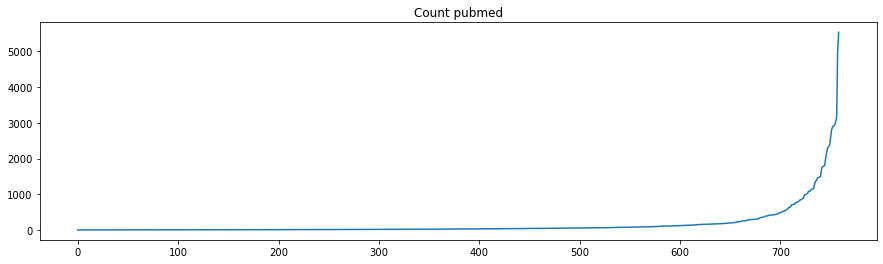

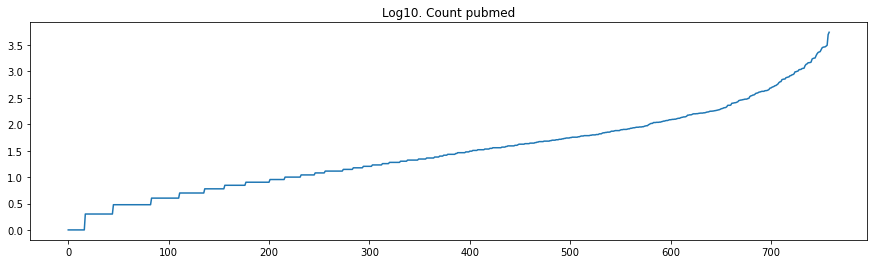

In [18]:
plt.figure(figsize = (15,4))
d = genes['count pubmed'].values
plt.plot(np.sort(d)) # genes['count pubmed'].values))
plt.title('Count pubmed')
plt.show()


plt.figure(figsize = (15,4))
d = np.log10( genes['count pubmed'].values )
plt.plot(np.sort(d)) # genes['count pubmed'].values))
plt.title('Log10. Count pubmed')
plt.show()


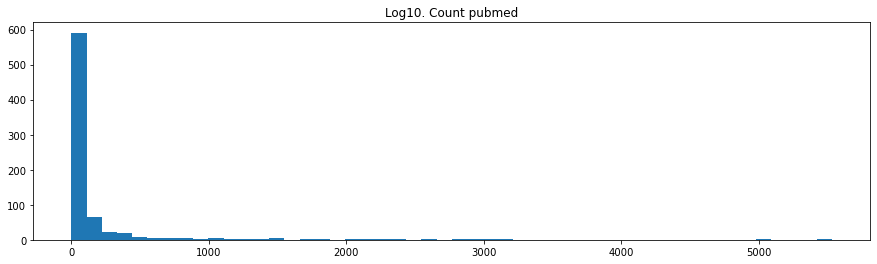

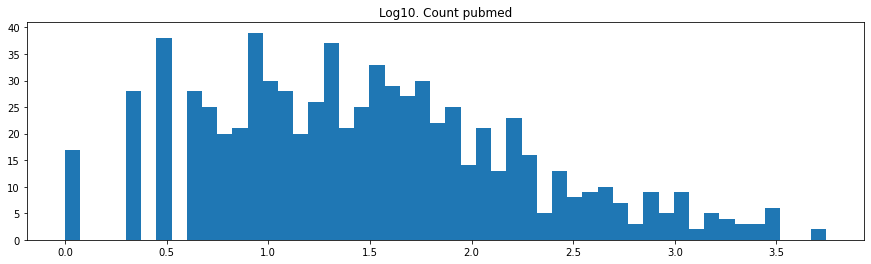

In [19]:

plt.figure(figsize = (15,4))
d = ( genes['count pubmed'].values )
plt.hist(d, bins = 50)
plt.title('Log10. Count pubmed')
plt.show()

plt.figure(figsize = (15,4))
d = np.log10( genes['count pubmed'].values )
plt.hist(d, bins = 50 )
plt.title('Log10. Count pubmed')
plt.show()


# Lengths of genes distribution

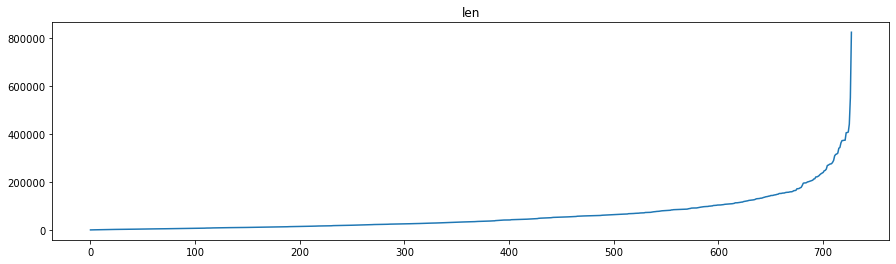

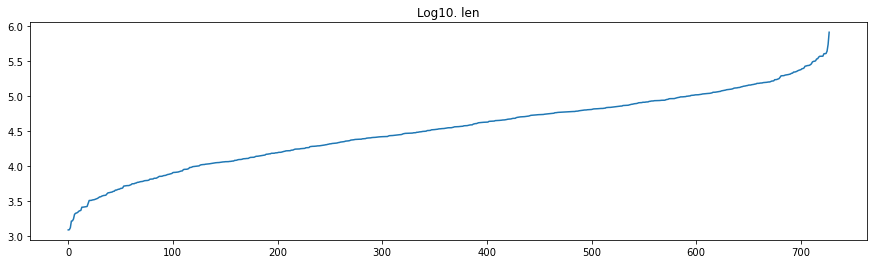

In [20]:
c = 'len'
plt.figure(figsize = (15,4))
d = genes[c].values
plt.plot(np.sort(d)) # genes['count pubmed'].values))
plt.title(c)
plt.show()


plt.figure(figsize = (15,4))
d = np.log10( genes[c].values )
plt.plot(np.sort(d)) # genes['count pubmed'].values))
plt.title('Log10. ' + c )
plt.show()

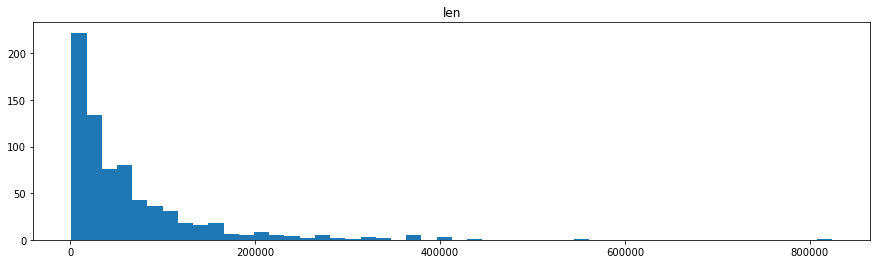

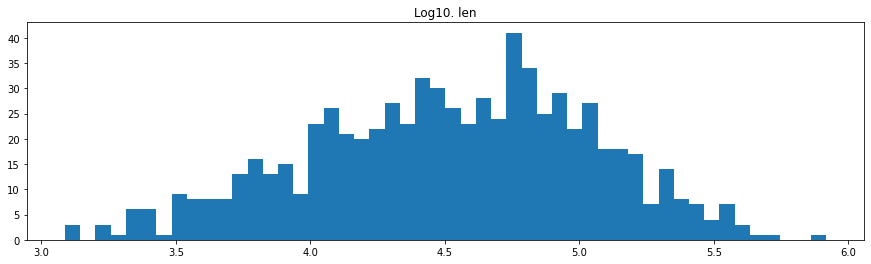

In [21]:
c = 'len'
plt.figure(figsize = (15,4))
d = ( genes[c].values )
plt.hist(d, bins = 50)
plt.title(c)
plt.show()

plt.figure(figsize = (15,4))
d = np.log10( genes[c].values )
plt.hist(d, bins = 50 )
plt.title('Log10. ' + c )
plt.show()

# Print "summary" info on selected genes

In [22]:
c = 'len'

g = genes[genes[c].notnull()].sort_values(c, ascending = False)

print('Head of sorted')
for i in range(10): # range(len(genes)):
    try:
        print(i,g['symbol'].iat[i],g['len'].iat[i], g['summary'].iat[i][:180])
    except:
        pass
    
print()
print('Tail of sorted')
for i in range(10): # range(len(genes)):
    i2 = len(g)-i
    try:
        print(i2,g['symbol'].iat[i2],g['len'].iat[i2], g['summary'].iat[i2][:180])
    except:
        pass
    


Head of sorted
0 INPP4B 824272.0 INPP4B encodes the inositol polyphosphate 4-phosphatase type II, one of the enzymes involved in phosphatidylinositol signaling pathways. This enzyme removes the phosphate group at 
1 PTPRK 551946.0 The protein encoded by this gene is a member of the protein tyrosine phosphatase (PTP) family. PTPs are known to be signaling molecules that regulate a variety of cellular processe
2 TIAM1 441556.0 This gene encodes a RAC1-specific guanine nucleotide exchange factor (GEF). GEFs mediate the exchange of guanosine diphosphate (GDP) for guanosine triphosphate (GTP). The binding o
3 CASK 408529.0 This gene encodes a calcium/calmodulin-dependent serine protein kinase. The encoded protein is a MAGUK (membrane-associated guanylate kinase) protein family member. These proteins 
4 APBB2 406687.0 The protein encoded by this gene interacts with the cytoplasmic domains of amyloid beta (A4) precursor protein and amyloid beta (A4) precursor-like protein 2. This protein cont

In [23]:
c = 'count pubmed' # 'len'

g = genes[genes[c].notnull()].sort_values(c, ascending = False)

print('Head of sorted')
for i in range(10): # range(len(genes)):
    try:
        print(i,g['symbol'].iat[i],g['len'].iat[i],g[c].iat[i], str(g['summary'].iat[i])[:180])
    except:
        pass
    
print()
print('Tail of sorted')
for i in range(10): # range(len(genes)):
    i2 = len(g)-i
    try:
        print(i2,g['symbol'].iat[i2],g['len'].iat[i2],g[c].iat[i2], str(g['summary'].iat[i2])[:180])
    except:
        pass
    


Head of sorted
0 EGFR 237599.0 5535.0 The protein encoded by this gene is a transmembrane glycoprotein that is a member of the protein kinase superfamily. This protein is a receptor for members of the epidermal growth 
1 APOE 3639.0 5003.0 The protein encoded by this gene is a major apoprotein of the chylomicron. It binds to a specific liver and peripheral cell receptor, and is essential for the normal catabolism of 
2 HIF1A 52745.0 3142.0 This gene encodes the alpha subunit of transcription factor hypoxia-inducible factor-1 (HIF-1), which is a heterodimer composed of an alpha and a beta subunit. HIF-1 functions as a
3 IL1B 7152.0 3024.0 The protein encoded by this gene is a member of the interleukin 1 cytokine family. This cytokine is produced by activated macrophages as a proprotein, which is proteolytically proc
4 AKT1 26402.0 2930.0 This gene encodes one of the three members of the human AKT serine-threonine protein kinase family which are often referred to as protein kinase B alph

In [24]:
for i in range(50): # range(len(genes)):
    try:
        print(i,genes['symbol'].iat[i], genes['summary'].iat[i][:120])
    except:
        pass

0 AARS1 The human alanyl-tRNA synthetase (AARS) belongs to a family of tRNA synthases, of the class II enzymes.  Class II tRNA s
1 ABCF1 The protein encoded by this gene is a member of the superfamily of ATP-binding cassette (ABC) transporters. ABC proteins
2 ABL1 This gene is a protooncogene that encodes a protein tyrosine kinase involved in a variety of cellular processes, includi
3 ACAA1 This gene encodes an enzyme operative in the beta-oxidation system of the peroxisomes. Deficiency of this enzyme leads t
4 ACLY ATP citrate lyase is the primary enzyme responsible for the synthesis of cytosolic acetyl-CoA in many tissues. The enzym
5 ADAM10 Members of the ADAM family are cell surface proteins with a unique structure possessing both potential adhesion and prot
6 ADH5 This gene encodes a member of the alcohol dehydrogenase family. Members of this family metabolize a wide variety of subs
7 PARP1 This gene encodes a chromatin-associated enzyme, poly(ADP-ribosyl)transferase, which modifi

In [25]:
for i in range(50): # range(len(genes)):
    i2 = len(genes)-i
    try:
        print(i2,genes['symbol'].iat[i2], genes['summary'].iat[i2][:120])
    except:
        pass

771 DIPK1A This gene encodes a member of the FAM69 family of cysteine-rich type II transmembrane proteins. These proteins localize 
769 SPRED2 SPRED2 is a member of the Sprouty (see SPRY1; MIM 602465)/SPRED family of proteins that regulate growth factor-induced a
768 TICAM1 This gene encodes an adaptor protein containing a Toll/interleukin-1 receptor (TIR) homology domain, which is an intrace
767 RPL39L This gene encodes a protein sharing high sequence similarity with ribosomal protein L39. Although the name of this gene 
765 COG7 The protein encoded by this gene resides in the golgi, and constitutes one of the 8 subunits of the conserved oligomeric
764 UBE3B The modification of proteins with ubiquitin is an important cellular mechanism for targeting abnormal or short-lived pro
763 H2BC12 Histones are basic nuclear proteins that are responsible for the nucleosome structure of the chromosomal fiber in eukary
762 ADO Human thiol dioxygenases include cysteine dioxygenase (CDO; MIM 603943)